In [39]:
import sys
import os

current_dir = os.getcwd()
module_path = os.path.join(current_dir, '..', 'external', 'SOTA-py', 'src')
module_path = os.path.normpath(module_path)

if module_path not in sys.path:
    sys.path.append(module_path)

new_folder_path = os.path.normpath(os.path.join(current_dir, '..', 'external', 'SOTA-py', 'graph'))

if new_folder_path not in sys.path:
    sys.path.append(new_folder_path)

from stochastic_graph import StochasticGraph
from preprocessing import bfReach, detReach, bfArcFlags, detArcFlags
from SOTA import StandardSOTASolver, SingleIterationSOTASolver
from deterministic_algorithms import Dijkstra
from utilities import Utils
from Grid_network_and_Gamma_distribution import Matrix

src_folder_path = os.path.normpath(os.path.join(current_dir, '..', 'src'))

if src_folder_path not in sys.path:
    sys.path.append(src_folder_path)

from R2L_train import GridNet, afGridNet, reachGridNet
from R2L_test import Test
from R2L_utilities import R2LTestFunctions

%matplotlib inline

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


======== STANDARD R2L =========

Object loaded from ./../instances/graphs/5x5-1.pkl
data loaded correctly.
SOTA path: [4, 9, 14, 19, 24]


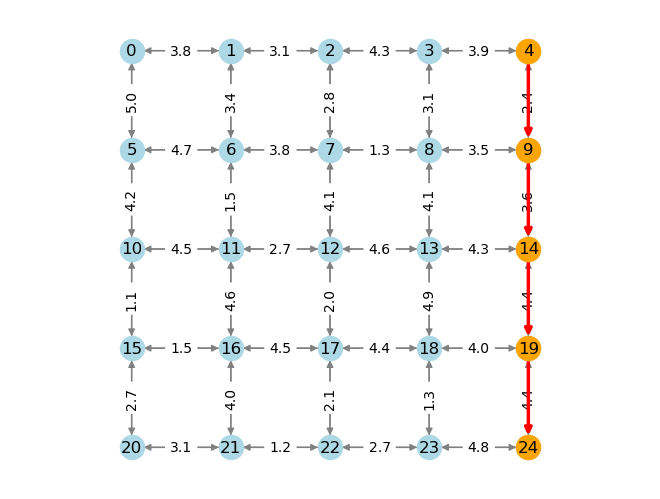


======== ARC-FLAGS R2L ========

Partitioning of the graph in 4 regions executed in 0.0030 seconds!
Arcflags computed!...
[ArcFlags] Pruned 9 edges for destination 24 (region 0).
Arcflags computed and graph pruned in 0.0080s
data loaded correctly.
SOTA path: [4, 9, 14, 19, 24]


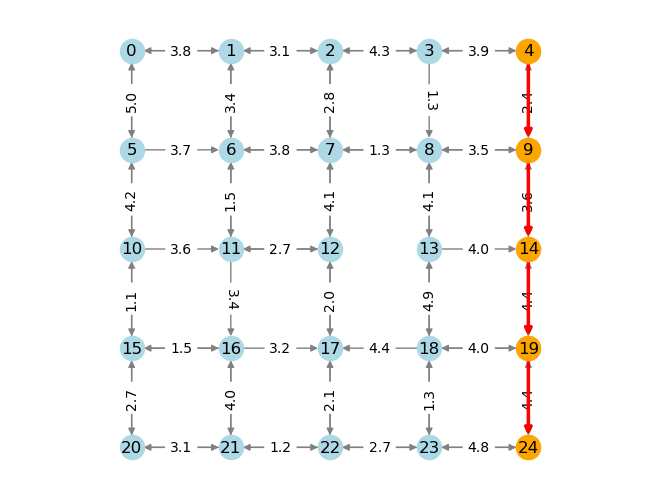

In [42]:
path_graph = "./../instances/graphs/5x5-1.pkl"
path_gn = "./../instances/trained/grid_5x5_test-gn.pkl"
path_af = "./../instances/trained/grid_5x5_test-af.pkl"

R2LTestFunctions.gn_af_path_comparison(path_graph, path_gn, path_af, 
    start_node=4, remaining_reward=25, dont_print=True, print_graph_path=True)

Object loaded from ./../instances/graphs/5x5-1.pkl
Reach values computeds...
Pruning nodes...Reach values computed and graph pruned (8 nodes) in 0.0123s
data loaded correctly.
SOTA path: [0, 5, 6, 11, 12, 17, 22, 23, 24]


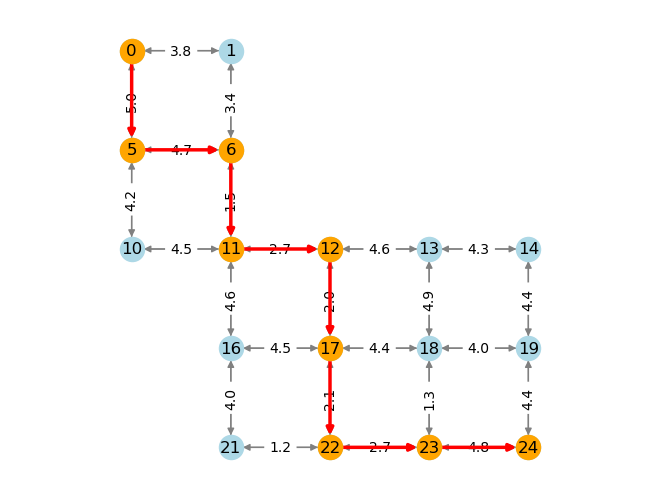

In [47]:
path_graph = "./../instances/graphs/5x5-1.pkl"
path_rh = "./../instances/trained/grid_5x5_test-rh.pkl"

graph = Utils.load_object(path_graph)
grid = reachGridNet(graph.get_adjacency_matrix(), graph.get_variance_matrix(), episode_number=500000, episode_lissage=50000)


test = Test(grid)
path = test.run(path_rh, start_node=0, remaining_reward=25, dont_print=True)

grid.get_graph().print_graph(path=path)



#R2LTestFunctions.path_run(path_graph, path_rh, grid_type="reach", start_node=0, remaining_reward = 25, dont_print=True,print_graph_path=True)